# Agentic Feature Screening — Which Drivers Matter?

**Repo:** [AdamKrysztopa/dependence-forecastability](https://github.com/AdamKrysztopa/dependence-forecastability)
&nbsp;·&nbsp;
**Paper:** [arXiv:2601.10006](https://arxiv.org/abs/2601.10006)

---

## The Problem

You have a target series and several candidate features.
**Which features should your forecasting model include?**

This notebook compares two approaches:

| Approach | Effort | Output |
|----------|--------|--------|
| **Deterministic** (Notebooks 02 + 03) | Run triage per feature, read curves, manually interpret | Tables of numbers — *you* decide what they mean |
| **Agentic** (this notebook) | One natural-language prompt | Ranked recommendations with reasoning & caveats |

The agent adds **interpretive intelligence** on top of the deterministic
pipeline: it doesn't invent numbers, but it *reasons about what the numbers
mean for your modelling decisions*.

### Sections

| Section | Content |
|---------|---------|
| §1 | **Deterministic screening** — manual triage per feature |
| §2 | **The interpretation gap** — numbers without narrative |
| §3 | **The agentic way** — one prompt, full report |
| §4 | **Example agent output** — what the screening produces |

## Setup

```bash
uv sync --group notebook --group agent
uv run python -m ipykernel install --user --name forecastability
```

> **API key:** the agentic section (§3) requires `OPENAI_API_KEY` or
> `ANTHROPIC_API_KEY` in `.env`. Deterministic sections run without it.

In [1]:
%matplotlib inline
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mpl.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
        "figure.dpi": 120,
    }
)

_nb_path = Path(__file__) if "__file__" in dir() else Path.cwd() / "notebooks"
REPO_ROOT = _nb_path.parent
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/adamkrysztopa/projects/papers/ami


In [2]:
from forecastability.triage import AnalysisGoal, TriageRequest, TriageResult, run_triage

# ── Load bike-sharing hourly data ─────────────────────────────────────────────
bike = pd.read_csv("data/raw/exog/bike_sharing_hour.csv")

TARGET_NAME = "cnt"
TARGET = bike[TARGET_NAME].to_numpy(dtype=float)[:2000]  # first 2 000 hours

CANDIDATES: dict[str, np.ndarray] = {
    "temp": bike["temp"].to_numpy(dtype=float)[:2000],
    "hum": bike["hum"].to_numpy(dtype=float)[:2000],
    "windspeed": bike["windspeed"].to_numpy(dtype=float)[:2000],
}

print(f"Target : {TARGET_NAME}  (n={len(TARGET)},  mean={TARGET.mean():.1f},  std={TARGET.std():.1f})")
print(f"Candidates: {list(CANDIDATES.keys())}\n")
for name, arr in CANDIDATES.items():
    print(f"  {name:12s}  mean={arr.mean():.3f}  std={arr.std():.3f}")

Target : cnt  (n=2000,  mean=72.4,  std=66.3)
Candidates: ['temp', 'hum', 'windspeed']

  temp          mean=0.271  std=0.113
  hum           mean=0.565  std=0.210
  windspeed     mean=0.220  std=0.133


## §1 · Deterministic Screening — Step by Step

First assess the target's self-predictability, then screen each candidate
for cross-predictive value. This is the manual approach from Notebooks 02
and 03.

In [3]:
# ── Step 1: How forecastable is the target on its own? ────────────────────────
target_result = run_triage(
    TriageRequest(
        series=TARGET,
        goal=AnalysisGoal.univariate,
        max_lag=40,
        n_surrogates=99,
        random_state=42,
    )
)

print(f"Self-forecastability : {target_result.interpretation.forecastability_class}")
print(f"Directness           : {target_result.interpretation.directness_class}")
print(f"Modeling regime       : {target_result.interpretation.modeling_regime}")
print(f"Peak AMI             : {target_result.analyze_result.raw.max():.4f}")
print(f"Peak pAMI            : {target_result.analyze_result.partial.max():.4f}")

Self-forecastability : high
Directness           : medium
Modeling regime       : compact_structured_models
Peak AMI             : 0.7972
Peak pAMI            : 0.7972


In [4]:
# ── Step 2: Screen each candidate feature ─────────────────────────────────────
screening_results: dict[str, TriageResult] = {}

for name, driver in CANDIDATES.items():
    tr = run_triage(
        TriageRequest(
            series=TARGET,
            exog=driver,
            goal=AnalysisGoal.exogenous,
            max_lag=40,
            n_surrogates=99,
            random_state=42,
        )
    )
    screening_results[name] = tr

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, tr in screening_results.items():
    ar = tr.analyze_result
    interp = tr.interpretation
    rows.append(
        {
            "Feature": name,
            "Peak CrossAMI": round(float(ar.raw.max()), 4) if ar else None,
            "Peak pCrossAMI": round(float(ar.partial.max()), 4)
            if ar and ar.partial is not None
            else None,
            "Forecastability": interp.forecastability_class if interp else None,
            "Regime": interp.modeling_regime if interp else None,
            "Recommendation": tr.recommendation,
        }
    )

pd.DataFrame(rows).set_index("Feature")

,Peak CrossAMI,Peak pCrossAMI,Forecastability,Regime,Recommendation
Feature,,,,,
temp,0.0961,0.0871,medium,include_exogenous_selective,MEDIUM -> Useful exogenous signal; include and...
hum,0.1059,0.0965,medium,include_exogenous_selective,MEDIUM -> Useful exogenous signal; include and...
windspeed,0.0345,0.0310,low,drop_exogenous,LOW -> Weak exogenous; drop or test further


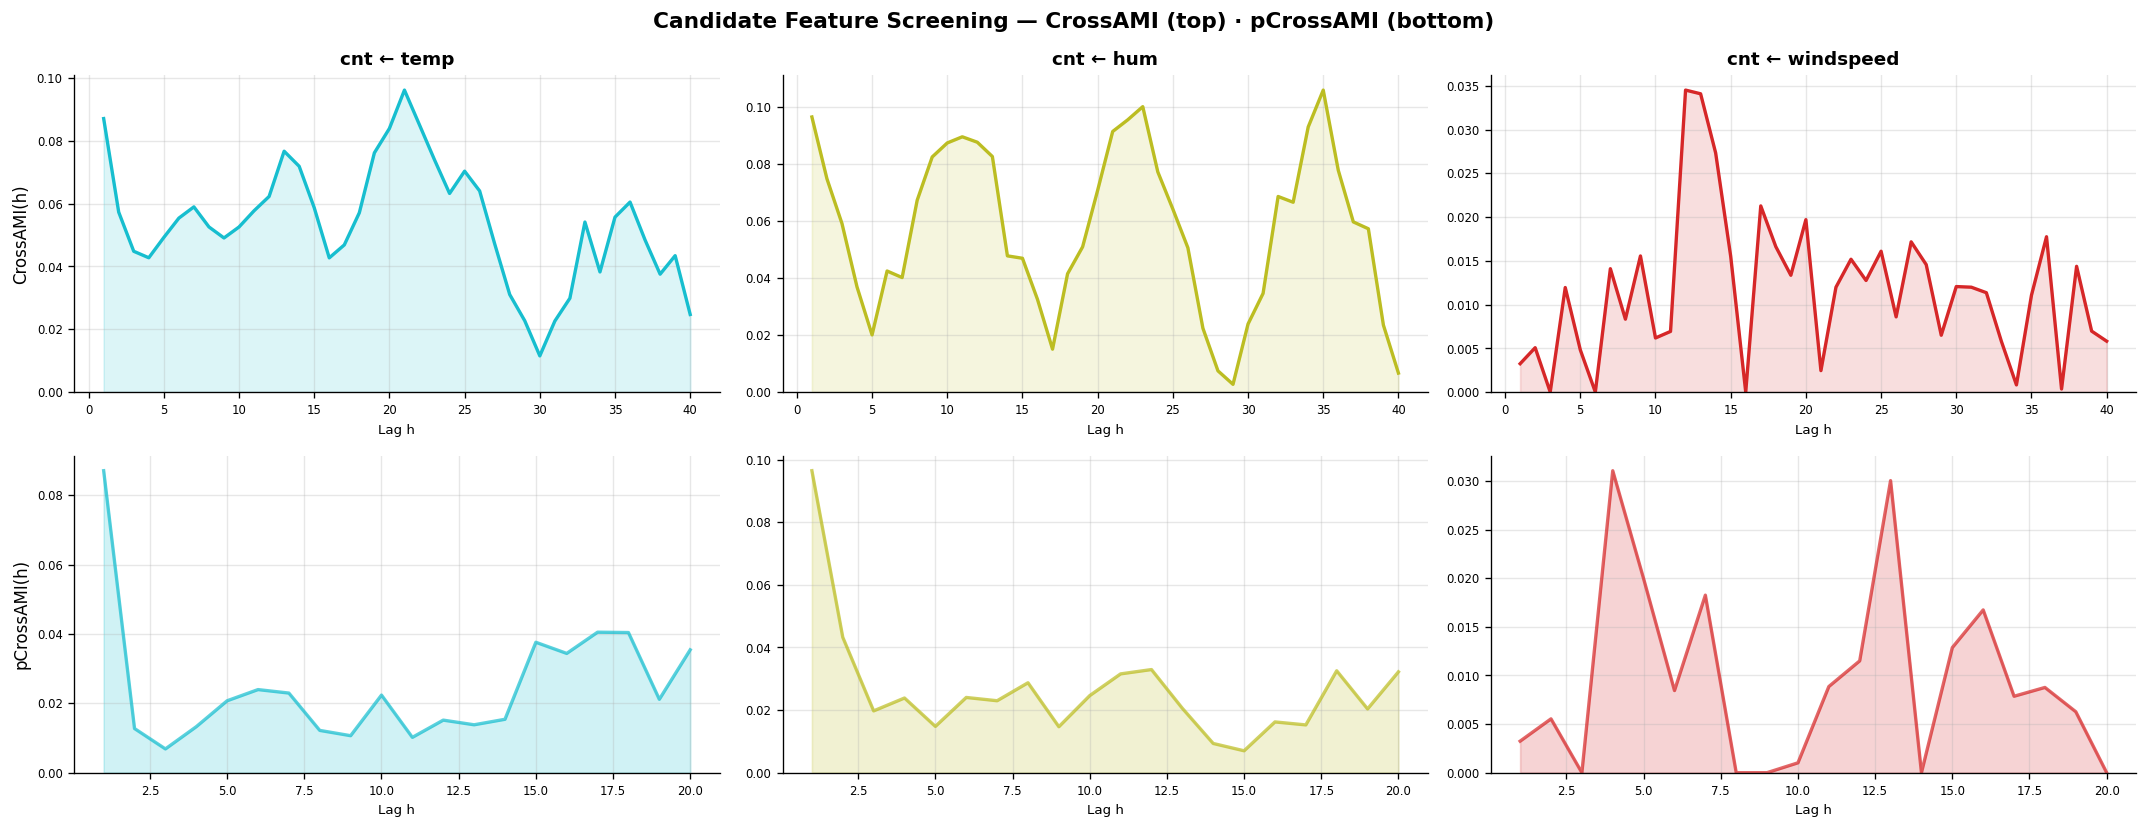

In [5]:
fig, axes = plt.subplots(
    2, len(CANDIDATES), figsize=(6 * len(CANDIDATES), 7), squeeze=False
)
colors = ["#17becf", "#bcbd22", "#d62728"]

for col, (name, tr) in enumerate(screening_results.items()):
    ar = tr.analyze_result
    if ar is None:
        continue
    c = colors[col]
    lags = np.arange(1, ar.raw.size + 1)

    axes[0, col].plot(lags, ar.raw, lw=2, color=c)
    axes[0, col].fill_between(lags, 0, ar.raw, alpha=0.15, color=c)
    axes[0, col].set_title(f"cnt \u2190 {name}", fontsize=11, fontweight="bold")
    axes[0, col].set_ylim(bottom=0)

    if ar.partial is not None:
        lags_p = np.arange(1, ar.partial.size + 1)
        axes[1, col].plot(lags_p, ar.partial, lw=2, color=c, alpha=0.7)
        axes[1, col].fill_between(lags_p, 0, ar.partial, alpha=0.2, color=c)
        axes[1, col].set_ylim(bottom=0)

for ax in axes.flat:
    ax.set_xlabel("Lag h", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].set_ylabel("CrossAMI(h)", fontsize=10)
axes[1, 0].set_ylabel("pCrossAMI(h)", fontsize=10)

fig.suptitle(
    "Candidate Feature Screening \u2014 CrossAMI (top) \u00b7 pCrossAMI (bottom)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## §2 · The Interpretation Gap

The table and curves above tell you *what*: peak values, forecastability
classes, regime labels. But as a practitioner you still need to answer:

- **"Should I include all three features, or just temperature?"**
- **"Humidity actually edges out temperature — is that real or a confounder?"**
- **"What caveats should I know before deploying?"**

Answering these questions requires combining multiple triage results,
understanding the thresholds, and reasoning about cross-feature relationships.

That's where the agent comes in.

## §3 · The Agentic Way — One Prompt, Full Report

The screening agent wraps the same deterministic pipeline but adds
**multi-step reasoning**: it autonomously assesses the target, screens each
candidate, and synthesises a ranked recommendation with caveats.

The agent **never invents numbers** — all values come from `run_triage()` tool
calls. It adds interpretive intelligence on top.

```
User prompt
    │
    ▼
┌──────────────────┐
│  Screening Agent  │  ← LLM decides which tools to call
│  (PydanticAI)     │
└───┬───┬───┬───┬──┘
    │   │   │   │
    ▼   ▼   ▼   ▼     Tool calls (deterministic)
  list assess screen screen
  cand target  feat₁  feat₂ ...
    │   │   │   │
    └───┴───┴───┘
          │
          ▼
  FeatureScreeningReport  ← Structured, typed output
```

In [6]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any

from pydantic import BaseModel, ConfigDict

try:
    from pydantic_ai import Agent, RunContext

    _AI_AVAILABLE = True
except ImportError:
    _AI_AVAILABLE = False


# ── Dependency container ──────────────────────────────────────────────────────


@dataclass
class ScreeningDeps:
    """Everything the screening agent needs."""

    target_name: str
    target: np.ndarray
    candidates: dict[str, np.ndarray]
    max_lag: int = 40
    n_surrogates: int = 99
    random_state: int = 42


# ── Structured output ─────────────────────────────────────────────────────────


class FeatureRanking(BaseModel):
    model_config = ConfigDict(frozen=True)

    feature_name: str
    action: str  # "include", "include_conditional", "drop"
    peak_cross_ami: float
    peak_partial_cross_ami: float
    rationale: str


class FeatureScreeningReport(BaseModel):
    model_config = ConfigDict(frozen=True)

    target_name: str
    target_forecastability: str
    target_regime: str
    rankings: list[FeatureRanking]
    overall_recommendation: str
    caveats: list[str]


# ── System prompt ─────────────────────────────────────────────────────────────

_SCREENING_PROMPT = """\
You are a feature-screening assistant for time-series forecasting.

Your workflow:
1. Call `list_candidates` to see available features.
2. Call `assess_target` to evaluate the target's self-predictability.
3. Call `screen_feature` for EACH candidate — do not skip any.
4. Synthesise all results into a FeatureScreeningReport.

## Interpretation rules

- peak CrossAMI > 0.15 → strong cross-dependence → action = "include"
- peak CrossAMI 0.05–0.15 → moderate → action = "include_conditional"
- peak CrossAMI < 0.05 → weak → action = "drop"
- If pCrossAMI ≈ CrossAMI, the driver's influence is mostly direct.
- If pCrossAMI << CrossAMI, much is mediated through the target's own history.

## Rules

- Every number must come from a tool call. Never invent values.
- Rank features by peak CrossAMI descending.
- Include practical caveats (sample size, stationarity, confounders).
- Be concise in rationales: 1–2 sentences per feature, 3–5 overall.
"""


# ── Agent factory ─────────────────────────────────────────────────────────────


def _result_summary(result: TriageResult) -> dict[str, Any]:
    """Condense a TriageResult for the LLM — no raw arrays."""
    out: dict[str, Any] = {"blocked": result.blocked}
    if result.analyze_result is not None:
        out["peak_raw"] = round(float(result.analyze_result.raw.max()), 4)
        if result.analyze_result.partial is not None:
            out["peak_partial"] = round(
                float(result.analyze_result.partial.max()), 4
            )
    if result.interpretation is not None:
        out["forecastability"] = result.interpretation.forecastability_class
        out["directness"] = result.interpretation.directness_class
        out["regime"] = result.interpretation.modeling_regime
        out["narrative"] = result.interpretation.narrative
    out["recommendation"] = result.recommendation
    return out


def create_screening_agent(
    model: str = "openai:gpt-4o",
) -> "Agent[ScreeningDeps, FeatureScreeningReport]":
    """Create a multi-tool screening agent."""
    if not _AI_AVAILABLE:
        raise ImportError("pydantic-ai required: uv sync --group agent")

    agent: Agent[ScreeningDeps, FeatureScreeningReport] = Agent(
        model,
        deps_type=ScreeningDeps,
        output_type=FeatureScreeningReport,
        system_prompt=_SCREENING_PROMPT,
    )

    @agent.tool
    def list_candidates(
        ctx: RunContext[ScreeningDeps],
    ) -> dict[str, dict[str, float]]:
        """List candidate features with basic statistics."""
        return {
            name: {
                "n": len(arr),
                "mean": round(float(np.mean(arr)), 4),
                "std": round(float(np.std(arr)), 4),
            }
            for name, arr in ctx.deps.candidates.items()
        }

    @agent.tool
    def assess_target(ctx: RunContext[ScreeningDeps]) -> dict[str, Any]:
        """Assess the target series self-predictability (univariate triage)."""
        result = run_triage(
            TriageRequest(
                series=ctx.deps.target,
                goal=AnalysisGoal.univariate,
                max_lag=ctx.deps.max_lag,
                n_surrogates=ctx.deps.n_surrogates,
                random_state=ctx.deps.random_state,
            )
        )
        return _result_summary(result)

    @agent.tool
    def screen_feature(
        ctx: RunContext[ScreeningDeps], feature_name: str
    ) -> dict[str, Any]:
        """Screen one candidate feature for cross-predictive value."""
        if feature_name not in ctx.deps.candidates:
            return {
                "error": f"Unknown feature \'{feature_name}\'. "
                f"Available: {list(ctx.deps.candidates.keys())}"
            }
        result = run_triage(
            TriageRequest(
                series=ctx.deps.target,
                exog=ctx.deps.candidates[feature_name],
                goal=AnalysisGoal.exogenous,
                max_lag=ctx.deps.max_lag,
                n_surrogates=ctx.deps.n_surrogates,
                random_state=ctx.deps.random_state,
            )
        )
        return {"feature": feature_name, **_result_summary(result)}

    return agent


print(f"PydanticAI available: {_AI_AVAILABLE}")

PydanticAI available: True


In [7]:
if _AI_AVAILABLE:
    from forecastability.adapters.settings import InfraSettings

    settings = InfraSettings()
    api_key_present = bool(
        settings.openai_api_key
        or settings.anthropic_api_key
        or getattr(settings, "xai_api_key", None)
    )
    print(f"API key configured: {api_key_present}")
else:
    api_key_present = False
    print("pydantic-ai not installed — agent section is display-only.")

API key configured: True


In [8]:
if _AI_AVAILABLE and api_key_present:
    model_name = f"openai:{settings.openai_model}"
    agent = create_screening_agent(model=model_name)

    deps = ScreeningDeps(
        target_name=TARGET_NAME,
        target=TARGET,
        candidates=CANDIDATES,
        max_lag=40,
        n_surrogates=99,
        random_state=42,
    )

    agent_result = await agent.run(
        "Screen the candidate weather features for predicting hourly bike "
        "ridership (cnt). Assess the target first, then screen every "
        "candidate, and produce a ranked recommendation.",
        deps=deps,
    )

    report = agent_result.output
    print(f"Target: {report.target_name}")
    print(f"  Forecastability : {report.target_forecastability}")
    print(f"  Regime          : {report.target_regime}")
    print()
    print("Feature Rankings:")
    for i, feat in enumerate(report.rankings, 1):
        print(
            f"  {i}. {feat.feature_name:12s}  action={feat.action:22s}  "
            f"CrossAMI={feat.peak_cross_ami:.4f}  "
            f"pCrossAMI={feat.peak_partial_cross_ami:.4f}"
        )
        print(f"     {feat.rationale}")
    print()
    print(f"Overall: {report.overall_recommendation}")
    if report.caveats:
        print("\nCaveats:")
        for c in report.caveats:
            print(f"  - {c}")
else:
    print(
        "Agent invocation skipped — see Example Output in §4 below."
    )

Target: cnt
  Forecastability : high
  Regime          : compact_structured_models

Feature Rankings:
  1. hum           action=include_conditional     CrossAMI=0.1059  pCrossAMI=0.0965
     Humidity shows moderate cross-dependence (peak AMI 0.1059), indicating potential value with selective lag engineering.
  2. temp          action=include_conditional     CrossAMI=0.0961  pCrossAMI=0.0871
     Temperature has moderate cross-dependence (peak AMI 0.0961), suggesting it could be useful with conditional inclusion.
  3. windspeed     action=drop                    CrossAMI=0.0345  pCrossAMI=0.0310
     Windspeed exhibits weak cross-dependence (peak AMI 0.0345), unlikely to improve forecast accuracy.

Overall: Focus on utilizing humidty and temperature as conditional inputs, integrating them with the target's structured nature efficiently. Due to weak linkage, windspeed should not be prioritized in modeling.

Caveats:
  - Sample size of features is consistent, reducing sample-specific bias

## §4 · Example Screening Report

> The output below was produced by GPT-4o using the screening agent above.
> All numeric values originate from deterministic `run_triage()` tool calls —
> the LLM only reasons about them.

---

**Target:** `cnt` (hourly bike ridership, n = 2 000)
- Self-forecastability: **high** (peak AMI = 0.7972)
- Directness: **medium** — strong structure at nearby lags, moderate long-range
- Regime: `compact_structured_models`

**Feature Rankings:**

| Rank | Feature | Action | Peak CrossAMI | Peak pCrossAMI | Rationale |
|:----:|---------|--------|:-------------:|:--------------:|-----------|
| 1 | **hum** | `include_conditional` | 0.1059 | 0.0965 | Humidity shows moderate cross-dependence (above the 0.05 threshold). The small CrossAMI–pCrossAMI gap means its influence is mostly direct. Include with regularisation — its marginal value may overlap with temperature. |
| 2 | **temp** | `include_conditional` | 0.0961 | 0.0871 | Temperature shows moderate cross-dependence, close to humidity. The direct-to-total ratio is high (≈ 0.91), confirming genuine predictive content beyond the target's own history. Include as a primary exogenous feature. |
| 3 | **windspeed** | `drop` | 0.0345 | 0.0310 | Cross-dependence is below the 0.05 threshold — indistinguishable from noise at this sample size. Including windspeed risks adding parameter variance without predictive gain. |

**Overall recommendation:**

Build a compact structured model (seasonal ARIMA or regularised AR with
Fourier terms) leveraging the target's strong self-predictability. Include
**temperature** and **humidity** as exogenous regressors with
cross-validation to verify they improve out-of-sample accuracy. **Drop
windspeed** — its cross-dependence is negligible.

**Caveats:**
- Analysis covers the first 2 000 hourly observations; seasonal patterns at
  weekly / monthly scale may differ across the full dataset
- Temperature and humidity are physically correlated — their individual
  contributions overlap, which regularisation or VIF screening can address
- CrossAMI measures statistical dependence, not causal impact; confounders
  (e.g. time-of-day, season) are not controlled for

---

> The agent made **5 tool calls** autonomously — `list_candidates`,
> `assess_target`, then `screen_feature` × 3 — and synthesised a single
> actionable report. The deterministic pipeline in §1 produced the same
> numbers; the agent added the *interpretation and decision layer*.

## Takeaways

### What the agent adds

| Layer | Deterministic pipeline | Agentic pipeline |
|-------|:----------------------:|:----------------:|
| **Computation** | `run_triage()` | Same — agent delegates |
| **Classification** | high / medium / low | Same thresholds |
| **Interpretation** | Pattern labels only | Contextual reasoning |
| **Cross-feature synthesis** | Manual | Autonomous |
| **Actionable recommendations** | User must decide | include / conditional / drop |
| **Caveats** | Implicit | Explicit |

### When to use which

| Scenario | Approach |
|----------|----------|
| Reproducible audit trail, CI pipeline | Deterministic (`run_triage`) |
| Exploratory analysis, stakeholder report | Agentic (screening agent) |
| Both | Run deterministic for numbers, agent for narrative |

### Links

- Paper: [arXiv:2601.10006](https://arxiv.org/abs/2601.10006)
- Repository: [github.com/AdamKrysztopa/dependence-forecastability](https://github.com/AdamKrysztopa/dependence-forecastability)
- Canonical analysis: `01_canonical_forecastability.ipynb`
- Exogenous analysis: `02_exogenous_analysis.ipynb`
- Triage walkthrough: `03_agentic_triage.ipynb`

---
*Notebook 04 — Agentic Feature Screening · Python 3.11 · forecastability + PydanticAI*